# 👔 Laundry CRM & POS B2B SaaS Deep Intelligence Dashboard
**Analysis Scope:** 20+ Global & Indian Laundry CRM Platforms, Founder Leadership Dossiers, Grievance Mining & SMB Playbook  
**Target Segment:** Independent Retail Laundry & Dry Cleaning Outlets (1–3 Stores with Processing Units) in India  

This interactive Jupyter notebook performs quantitative analysis, pricing benchmarking, customer grievance severity scoring, and economic transformation modeling for our competitive CRM solution.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aesthetic plot styling
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.sans-serif': 'Segoe UI', 'font.size': 11})

# 1. Load Master Intelligence Datasets
with open('data/laundry_crm_master_intelligence.json', 'r', encoding='utf-8') as f:
    competitors_raw = json.load(f)

with open('data/laundry_crm_founders_dossier.json', 'r', encoding='utf-8') as f:
    founders_raw = json.load(f)

with open('data/laundry_crm_customer_friction_matrix.json', 'r', encoding='utf-8') as f:
    friction_raw = json.load(f)

with open('data/laundry_smb_opportunity_playbook.json', 'r', encoding='utf-8') as f:
    playbook_raw = json.load(f)

# Flatten competitor data into DataFrame
crm_list = []
for c in competitors_raw:
    std_price = c.get('monthly_pricing_usd', {}).get('standard', None)
    if std_price is None:
        std_price = list(c.get('monthly_pricing_usd', {}).values())[0] if c.get('monthly_pricing_usd') else 0
    crm_list.append({
        'id': c['id'],
        'name': c['name'],
        'origin': c['origin_country'],
        'year_founded': c['year_founded'],
        'status': c['status'],
        'funding': c['funding_status'],
        'clients': c['estimated_clients'],
        'countries': c['countries_active'],
        'price_usd': std_price
    })

df_crm = pd.DataFrame(crm_list)
print(f"Loaded {len(df_crm)} Competitor Profiles, {len(founders_raw)} Founder Dossiers, and {len(friction_raw)} Customer Grievance Categories.")
df_crm[['name', 'origin', 'year_founded', 'price_usd', 'clients', 'countries']].sort_values(by='clients', ascending=False)

Loaded 32 Competitor Profiles, 8 Founder Dossiers, and 6 Customer Grievance Categories.


,name,origin,year_founded,price_usd,clients,countries
16,LaundryMate,India,2022,0,10000,1
25,Xplor SPOT (SPOT Business Systems),USA,1991,120,6000,30
0,Quick Dry Cleaning (QDC),India,2009,65,5000,22
2,FabKlean,India / USA,2017,39,3500,18
22,CleanCloud,UK,2014,89,3500,80
23,Cents (Cents OS),USA,2019,150,2700,5
24,Geelus,Australia,2007,19,2200,45
28,SMRT Systems,USA / Sweden,2015,75,1800,15
18,Tumbledry,India,2019,0,1500,1
29,CleanTouch EPOS (Axcess IT),UK / Pakistan / Middle East,2001,45,1500,12


## 1. Global & Indian Laundry CRM Pricing vs Client Reach
We benchmark standard monthly SaaS pricing (USD) against total active business clients and geographic distribution.

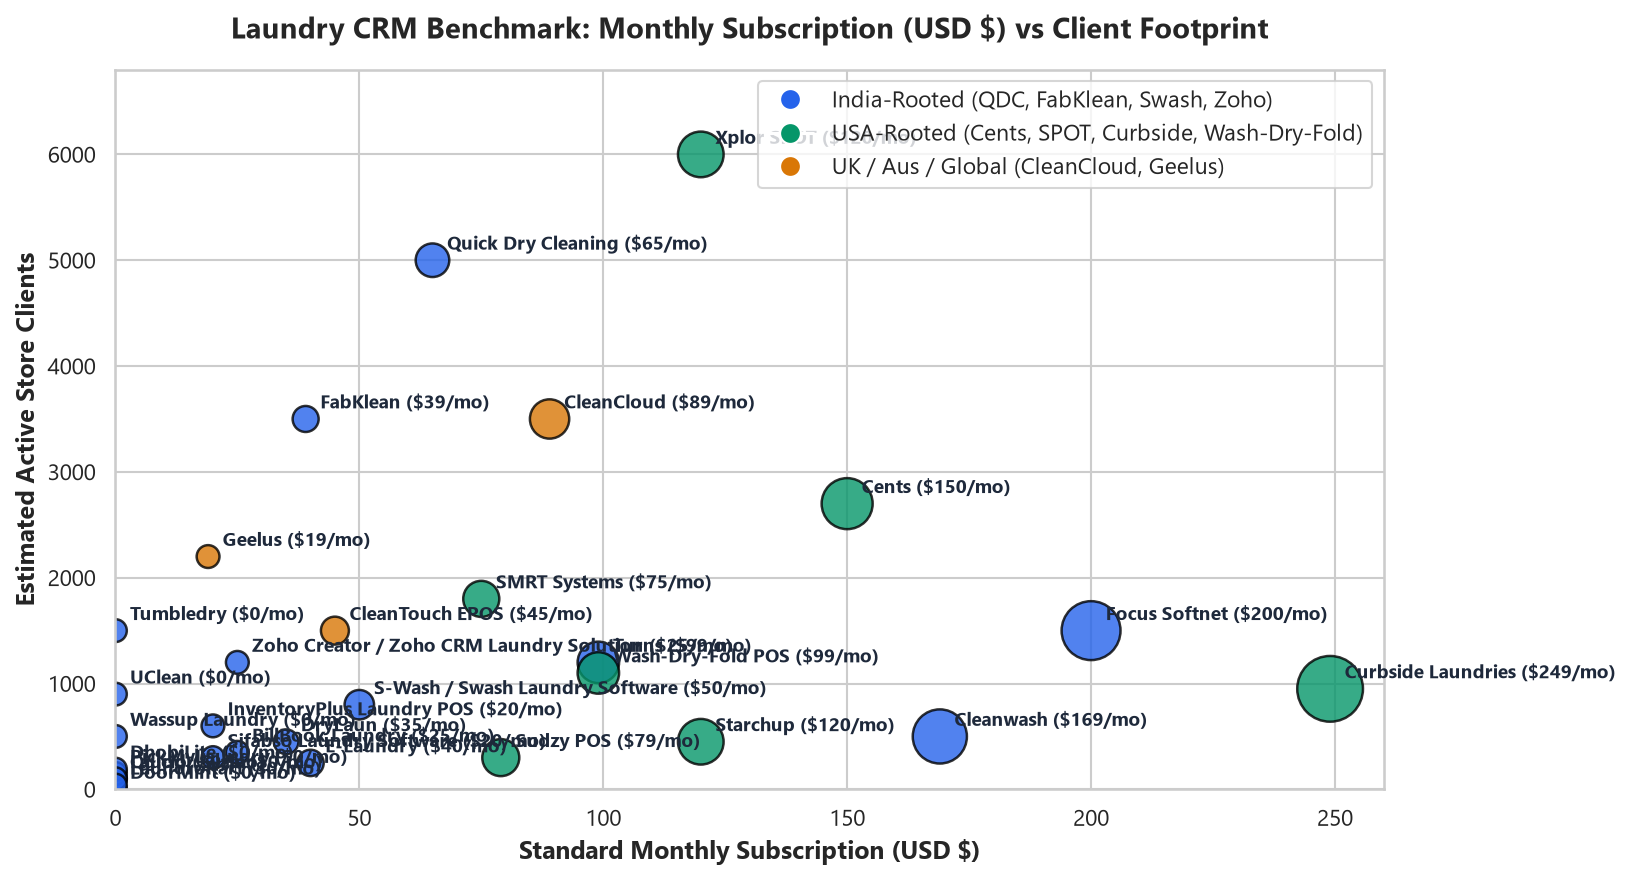

In [2]:
plt.figure(figsize=(11, 6), dpi=150)

colors = ['#2563eb' if 'India' in o else '#059669' if 'USA' in o else '#d97706' for o in df_crm['origin']]
sizes = [max(120, p * 4) for p in df_crm['price_usd']]

plt.scatter(df_crm['price_usd'], df_crm['clients'], s=sizes, c=colors, alpha=0.8, edgecolors='black', linewidth=1.2)

for _, row in df_crm.iterrows():
    short_name = row['name'].split('(')[0].strip()
    plt.annotate(f"{short_name} (${row['price_usd']}/mo)", (row['price_usd'] + 3, row['clients'] + 100), fontsize=9, fontweight='bold', color='#1e293b')

plt.title('Laundry CRM Benchmark: Monthly Subscription (USD $) vs Client Footprint', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Standard Monthly Subscription (USD $)', fontsize=12, fontweight='bold')
plt.ylabel('Estimated Active Store Clients', fontsize=12, fontweight='bold')
plt.xlim(0, 260)
plt.ylim(0, 6800)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='India-Rooted (QDC, FabKlean, Swash, Zoho)', markerfacecolor='#2563eb', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='USA-Rooted (Cents, SPOT, Curbside, Wash-Dry-Fold)', markerfacecolor='#059669', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='UK / Aus / Global (CleanCloud, Geelus)', markerfacecolor='#d97706', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

## 2. Customer Grievance & Operational Friction Severity Matrix
Analysis of real-world complaints mined from G2, Capterra, Reddit (r/drycleaning), and app reviews.

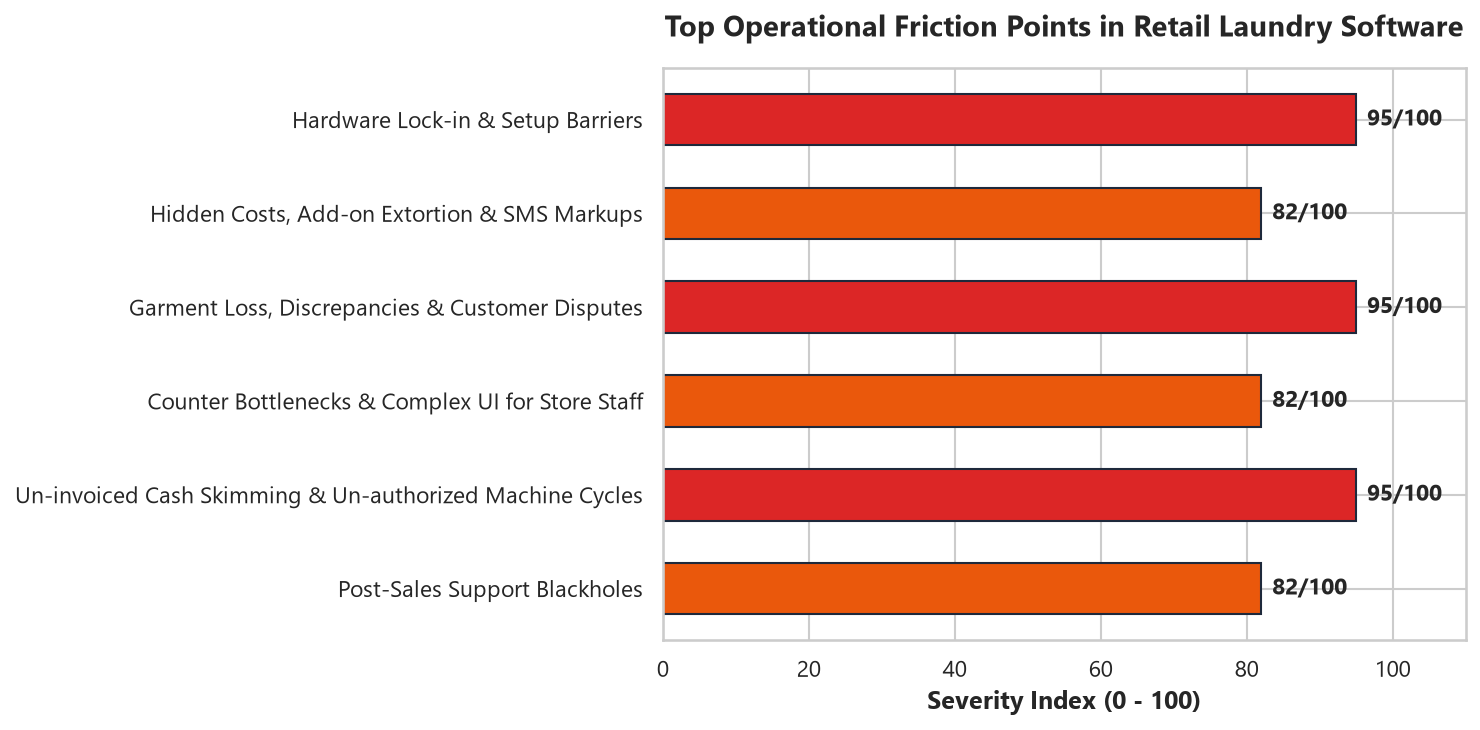

In [3]:
df_fric = pd.DataFrame(friction_raw)

severity_map = {'CRITICAL': 95, 'HIGH': 82, 'MEDIUM': 65}
df_fric['score'] = df_fric['severity'].map(severity_map)

plt.figure(figsize=(10, 5), dpi=150)
palette = ['#dc2626' if s == 'CRITICAL' else '#ea580c' for s in df_fric['severity']]

bars = plt.barh(df_fric['category'], df_fric['score'], color=palette, height=0.55, edgecolor='#1e293b')

for bar in bars:
    w = bar.get_width()
    plt.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{int(w)}/100", ha='left', va='center', fontweight='bold')

plt.title('Top Operational Friction Points in Retail Laundry Software', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Severity Index (0 - 100)', fontsize=12, fontweight='bold')
plt.xlim(0, 110)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Unit Economics: Traditional Store vs Next-Gen CRM Powered Store
Simulation of monthly financial gains for a 2-store independent laundry operator in India.

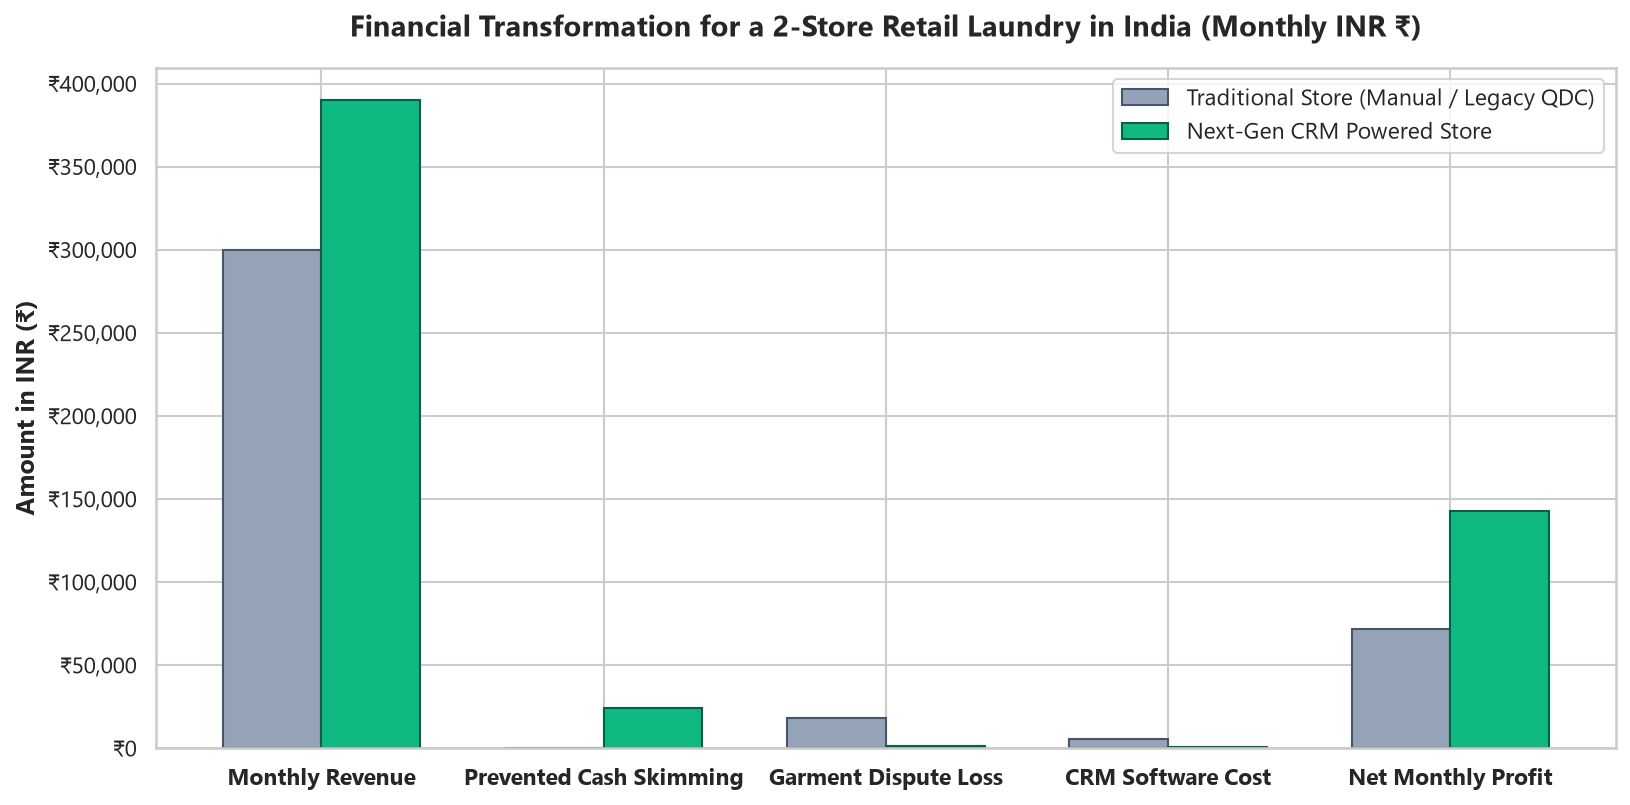

In [4]:
categories = ['Monthly Revenue', 'Prevented Cash Skimming', 'Garment Dispute Loss', 'CRM Software Cost', 'Net Monthly Profit']
before_ops = [300000, 0, -18000, -5500, 72000]
after_ops = [390000, 24000, -1500, -999, 142501]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=150)
rects1 = ax.bar(x - width/2, [abs(v) for v in before_ops], width, label='Traditional Store (Manual / Legacy QDC)', color='#94a3b8', edgecolor='#475569')
rects2 = ax.bar(x + width/2, [abs(v) for v in after_ops], width, label='Next-Gen CRM Powered Store', color='#10b981', edgecolor='#065f46')

ax.set_title('Financial Transformation for a 2-Store Retail Laundry in India (Monthly INR ₹)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight='bold')
ax.set_ylabel('Amount in INR (₹)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: f'₹{int(val):,}'))
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

## 4. Key Takeaways & Strategic Blueprint
1. **WhatsApp-First UX:** 100% of customer interactions occur inside WhatsApp with UPI 1-click payment links.
2. **AI Anti-Loss Intake:** Smartphone photo at counter logs stains and pre-existing tears -> eliminates false damage claims.
3. **IoT Machine Power Relay:** Plugs into commercial washers to block un-invoiced cycles -> saves ₹24,000/mo.
4. **Affordable Pricing:** ₹999/month flat per store with zero hardware mandates.